# Предобработка данных для GLM (трансформеры)

Ноутбук для настройки пайплайна предобработки перед обучением GLM. Трансформеры — из glm (`glm_transformers.py`), виджеты — из axiolyze (MultiTabSelector, ParametricDictionaryValueSelector). Схема данных задаётся загрузкой или созданием через мультитаб; дальше все шаги трансформеров настраиваются новыми виджетами, выход виджетов подаётся в конструкторы без адаптеров.

**Структура:**
1. Загрузка данных (файл или SQL)
2. Схема: служебные колонки и типы признаков в одном MultiTabSelector (7 вкладок: таргет, индекс, экспозиция, to_drop, force_cat, force_num, force_time)
3. Первый шаг: чтение и фильтрация (`GLMSmartDataFilterTransformation`)
4. Трансформеры по порядку: математика (степени, log, exp), даты, циклические, биннинг, target encoding, numeric→cat, группировка категорий, транслитерация — виджеты по-новому
5. Выбор типа модели и обучение
6. Анализ результата

**Куда пишутся результаты:**
- `export_model_results` → `model_analysis/{dataset_name}/` (Excel, HTML, графики)
- `savem` → `models/{dataset_name}/` (модель, пайплайн, metadata, данные)

## 1. Импорт библиотек

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from ipyfilechooser import FileChooser
from IPython.display import display

# Путь к корню проекта для axiolyze
sys.path.append('..')

# Трансформеры — из glm
from glm_transformers import *
# Виджеты и схема — из axiolyze (нужен путь к корню проекта)
from axiolyze.notebooks.widgets import *
from axiolyze.core.schema import DataSchema, update_schema_after_transformation, schema_to_selection_dict
from axiolyze.core.statistics import compute_stability_for_columns_direct, compute_levels_for_columns_direct
# support и glm_analysis — из glm
from support import savez, GLMModelSelector, check_design_matrix_stability, save_pre_translit
from model_io import savem
from glm_analysis import *

def read_df_from_sql(query, sql_server_name=None, db_name=None, **kwargs):
    """Загрузка из SQL: vsk_omtl или fallback на sqlalchemy."""
    try:
        from vsk_omtl import read_df_from_sql as custom_read_sql
        return custom_read_sql(query=query, sql_server_name=sql_server_name, db_name=db_name, **kwargs)
    except (ImportError, NameError):
        try:
            from sqlalchemy import create_engine
            cs = kwargs.pop('connection_string', 'sqlite:///:memory:')
            if sql_server_name and db_name:
                cs = f"mssql+pyodbc://@{sql_server_name}/{db_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
            engine = create_engine(cs)
            try:
                return pd.read_sql(query, con=engine, **kwargs)
            finally:
                engine.dispose()
        except Exception as e:
            raise ValueError(f"Не удалось загрузить данные из SQL: {e}")

%load_ext autoreload
%autoreload 2

## 2. Настройки

In [2]:
dataset_name = 'research_transformers'
schema_path = Path(f'{dataset_name}_schema.yaml')
schema_pipeline_path = Path(f'{dataset_name}_schema_pipeline.yaml')
file_extension = 'feather'  # или 'csv' - для сохранения
new_exposure_name = 'new_exposure'
schema = None
schema_pipeline = None

## 3. Загрузка данных

**Цель:** Загрузить сырые данные из файла (CSV/Feather) или по SQL. Дальше задаются служебные колонки и типы признаков, затем собирается пайплайн предобработки.

In [3]:
fc_data = FileChooser(
    path='.',
    filename='',
    filter_pattern=('*.csv', '*.feather'),
    title='ВАРИАНТ 1: Выберите файл данных (CSV или Feather)'
)
display(fc_data)

fc_sql = FileChooser(
    path='.',
    filename='',
    filter_pattern=('*.sql',),
    title='ВАРИАНТ 2: Выберите файл с SQL запросом'
)
display(fc_sql)

FileChooser(path='C:\Users\puls\PycharmProjects\glm', filename='', title='ВАРИАНТ 1: Выберите файл данных (CSV…

FileChooser(path='C:\Users\puls\PycharmProjects\glm', filename='', title='ВАРИАНТ 2: Выберите файл с SQL запро…

In [4]:
if fc_data.selected:
    file_path = fc_data.selected
    if file_path.endswith('.csv'):
        df_raw = pd.read_csv(file_path)
    elif file_path.endswith('.feather'):
        df_raw = pd.read_feather(file_path)
    print(f"Загружено из файла: {file_path}")
    print(f"Загружено строк: {df_raw.shape[0]}, колонок: {df_raw.shape[1]}")
elif fc_sql.selected:
    with open(fc_sql.selected, 'r', encoding='utf-8') as f:
        query = f.read()
    sql_server_name = None
    db_name = None
    df_raw = read_df_from_sql(query=query, sql_server_name=sql_server_name, db_name=db_name, n_jobs=1, debug_sql=False)
    print(f"Загружено из SQL: {fc_sql.selected}")
    print(f"Загружено строк: {df_raw.shape[0]}, колонок: {df_raw.shape[1]}")
else:
    print("Не выбран источник данных. Выберите файл или SQL запрос выше.")
    df_raw = None

if df_raw is not None:
    print("\nПервые строки:")
    display(df_raw.head(2))
    print("\nТипы данных:")
    print(df_raw.dtypes)
    print("\nПропуски:")
    print(df_raw.isnull().sum())

Загружено из файла: C:\Users\puls\PycharmProjects\glm\unbalanced_dataset_train.csv
Загружено строк: 10000, колонок: 6

Первые строки:


,Unnamed: 0,Марка,YearMonth,Страховая сумма,Количество дней от события до урегулирования,Оценка убытка
0,0,Жигули,202404,374512.239140,43.0,98674
1,1,Лада Самара,202501,624627.110258,13.0,160331



Типы данных:
Unnamed: 0                                        int64
Марка                                            object
YearMonth                                         int64
Страховая сумма                                 float64
Количество дней от события до урегулирования    float64
Оценка убытка                                     int64
dtype: object

Пропуски:
Unnamed: 0                                        0
Марка                                             0
YearMonth                                         0
Страховая сумма                                   0
Количество дней от события до урегулирования    100
Оценка убытка                                     0
dtype: int64


## 4. Схема: загрузка из файла или создание виджетом

Сначала можно загрузить сохранённую схему (опционально). Если не загружена — создайте схему виджетом с 7 вкладками: таргет, индекс, экспозиция, to_drop, force_cat, force_num, force_time. После выбора в виджете нажмите «Сохранить все», затем выполните ячейку извлечения.

In [5]:
# Загрузка сохранённой схемы (опционально). Если не выберете файл — создайте схему виджетом ниже.
fc_schema = FileChooser(path='.', filename='', filter_pattern=('*.yaml', '*.yml'), title='Загрузить сохранённую схему (опционально)')
display(fc_schema)

FileChooser(path='C:\Users\puls\PycharmProjects\glm', filename='', title='Загрузить сохранённую схему (опциона…

In [6]:
# Загрузка схемы из файла (если выбрана). При повторном запуске без выбора файла schema не сбрасывается.
fc_schema = globals().get('fc_schema')
if fc_schema and fc_schema.selected and df_raw is not None:
    try:
        schema = DataSchema.load(fc_schema.selected, df=df_raw)
        print("Схема успешно загружена из файла")
        print(f"  Таргеты: {schema.target_columns}")
        print(f"  Индексы: {schema.index_columns}")
        print(f"  Экспозиция: {schema.exposure_column}")
    except ValueError as e:
        print(f"Схема не соответствует данным: {e}")
        schema = None
    except FileNotFoundError:
        print("Файл схемы не найден. Создайте новую схему ниже.")
        schema = None
    except Exception as e:
        print(f"Файл не является схемой DataSchema (например, содержит sklearn Pipeline): {e}")
        schema = None
elif schema is not None:
    print("Схема уже определена (загружена или создана ранее). Для перезагрузки выберите файл выше.")
else:
    print("Схема не выбрана. Создайте новую схему через виджеты ниже.")

Схема успешно загружена из файла
  Таргеты: ['Оценка убытка']
  Индексы: ['Unnamed: 0']
  Экспозиция: Create new


In [7]:
# Виджет создания схемы — показывается когда есть df_raw
if 'df_raw' in dir() and df_raw is not None:
    schema_data = {c: {'value': str(df_raw[c].iloc[0]) if len(df_raw) else c} for c in df_raw.columns}
    schema_tabs = [
        {'name': 'target', 'title': 'Таргет', 'columns': None, 'create_new': False, 'block_others': True, 'max_selections': 1, 'required': True},
        {'name': 'index', 'title': 'Индекс', 'columns': None, 'create_new': True, 'block_others': True, 'max_selections': None, 'required': True},
        {'name': 'exposure', 'title': 'Экспозиция', 'columns': None, 'create_new': True, 'block_others': True, 'max_selections': None, 'required': True},
        {'name': 'to_drop', 'title': 'Удалить', 'columns': None, 'create_new': False, 'block_others': True, 'max_selections': None},
        {'name': 'force_cat', 'title': 'force_cat', 'columns': None, 'create_new': False, 'block_others': True, 'max_selections': None},
        {'name': 'force_num', 'title': 'force_num', 'columns': None, 'create_new': False, 'block_others': True, 'max_selections': None},
        {'name': 'force_time', 'title': 'force_time', 'columns': None, 'create_new': False, 'block_others': True, 'max_selections': None},
    ]
    initial_sel = schema_to_selection_dict(schema, schema_tabs) if schema else None
    schema_ui = MultiTabSelector(schema_data, schema_tabs, initial_selection=initial_sel)
    display(schema_ui)
    if initial_sel:
        schema_ui.apply_selection(initial_sel)
else:
    schema_ui = None

MultiTabSelector(children=(Tab(children=(_TabContent(children=(BodyToggleButtonList(children=(CustomToggleButt…

In [10]:
# Схема — единственный источник. Всегда читаем из виджета при его наличии.
if schema_ui is None:
    raise RuntimeError("Виджет не создан. Сначала загрузите данные и выполните ячейку с виджетом выше.")
target_ = list(getattr(schema_ui.target, 'selected', []))
index_ = list(getattr(schema_ui.index, 'selected', []))
exposure_ = list(getattr(schema_ui.exposure, 'selected', []))
to_drop = list(getattr(schema_ui.to_drop, 'selected', []))
force_cat = list(getattr(schema_ui.force_cat, 'selected', []))
force_num = list(getattr(schema_ui.force_num, 'selected', []))
force_time = list(getattr(schema_ui.force_time, 'selected', []))
target = target_[0] if target_ else None
schema = DataSchema.from_dataframe(
    df_raw,
    target=target,
    index=index_,
    exposure=exposure_[0] if exposure_ else None,
    exposure_list=exposure_,
    force_categorical=force_cat,
    force_numeric=force_num,
    trash_columns=to_drop,
    datetime_columns=force_time,
)
schema.force_categorical = force_cat
schema.force_numeric = force_num
schema.save(schema_path)
print(f"Схема сохранена: {schema_path}")

feat = schema.numeric_columns + schema.categorical_columns
print(f"Таргет: {schema.target_columns[0] if schema.target_columns else None}, индекс: {list(schema.index_columns or [])}, экспозиция: {list(schema.exposure_columns or ([schema.exposure_column] if schema.exposure_column else []))}")
print(f"to_drop: {len(schema.excluded_columns)}, force_cat: {len(getattr(schema,'force_categorical',[]) or [])}, force_num: {len(getattr(schema,'force_numeric',[]) or [])}, force_time: {len(schema.datetime_columns or [])}")
print(f"Признаки: {len(feat)}")


Схема сохранена: research_transformers_schema.yaml
Таргет: Оценка убытка, индекс: ['Unnamed: 0'], экспозиция: ['Create new']
to_drop: 0, force_cat: 1, force_num: 2, force_time: 0
Признаки: 4


## 5. Первый шаг пайплайна: чтение и фильтрация

`GLMSmartDataFilterTransformation` удаляет мусорные колонки, задаёт типы, создаёт при необходимости индекс/экспозицию.

In [69]:
preprocessing_4glm_pipeline = Pipeline(steps=[])
prepro_counter = 0

idx = list(schema.index_columns or [])
exp = list(schema.exposure_columns or ([schema.exposure_column] if schema.exposure_column else []))
feat = schema.numeric_columns + schema.categorical_columns

first_step = GLMSmartDataFilterTransformation(
    trash_columns=list(schema.excluded_columns),
    filter_config={},
    index_columns=idx,
    exposure_columns=exp,
    target_column=schema.target_columns[0] if schema.target_columns else None,
    force_categorical=list(getattr(schema, 'force_categorical', []) or []),
    force_numeric=list(getattr(schema, 'force_numeric', []) or []),
    force_datetime=list(schema.datetime_columns or []),
    new_index_name='new_index',
    new_exposure_name=new_exposure_name,
)

x_columns = feat + [c for c in idx if c != 'Create new'] + ([exp[0]] if exp and exp[0] != 'Create new' else [])
_tc = schema.target_columns[0] if schema.target_columns else None
X, y = df_raw[x_columns], df_raw[_tc]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df_model = pd.concat([X_train, y_train], axis=1)
df_test_raw = pd.concat([X_test, y_test], axis=1)

df_model = first_step.fit_transform(df_model)
fs_data = first_step.get_data_schema()
fs_data['user_excluded_columns'] = []
for k in ('numeric_columns', 'categorical_columns', 'datetime_columns'):
    fs_data[k] = list(getattr(schema, k, None) or fs_data.get(k, []))
exp_list = list(schema.exposure_columns or ([schema.exposure_column] if schema.exposure_column else []))
schema_pipeline = DataSchema.from_filter_dict(fs_data, df=df_model, exposure_columns_override=exp_list)
schema_pipeline.save(schema_pipeline_path)
exposure = schema_pipeline.get('exposure_column')

prepro_counter += 1
preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_initial_reading', first_step))
#savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
print(f"Шаг {prepro_counter}: начальное чтение и фильтрация. Экспозиция: {exposure}")
df_model.head(2)


Шаг 1: начальное чтение и фильтрация. Экспозиция: new_exposure


,YearMonth,Страховая сумма,Количество дней от события до урегулирования,Марка,Unnamed: 0,Оценка убытка,new_exposure
9254,202408,3.180208e+06,15.0,Киа,9254,170661,1.0
1561,202309,3.158605e+06,6.0,Киа,1561,134191,1.0


In [15]:
#schema_pipeline #schema #, 


## 6. Числовые математические преобразования

ParametricDictionaryValueSelector: для каждой числовой колонки выбирается одно преобразование (log, exp, power_range или power_list). При выборе power в той же карточке проявляются поля «от/до/шаг» или «список». Выход виджета собирается в (features_to_transform, transformations) и подаётся в GLMMathematicalTransformation.

In [11]:
math_ui = None
if (schema_pipeline.get('numeric_columns') or []) == []:
    print("Нет числовых признаков для преобразований.")
else:
    math_tabs_config = [{**GLM_MATH_TRANSFORMER_PRESET['tab_config'], 'keys': schema_pipeline.get('numeric_columns') or [], 'option_to_config': GLM_MATH_TRANSFORMER_PRESET['option_to_config']}]
    math_ui = ParametricDictionaryValueSelector(math_tabs_config)
    display(math_ui)


ParametricDictionaryValueSelector(children=(Tab(children=(VBox(children=(HTML(value='<h4>Выберите значение (пр…

In [12]:
math_features, math_transformations_dict = (math_ui.get_transformer_input('math', GLM_MATH_TRANSFORMER_PRESET) if math_ui else ([], {}))

if math_features:
    prepro_counter += 1
    math_step = GLMMathematicalTransformation(
        features_to_transform=math_features,
        transformations=math_transformations_dict,
        keep_original=True
    )
    df_model = math_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, math_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_mathematical', math_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: математические преобразования добавлены.")
else:
    print("Мат. преобразования не выбраны — шаг пропущен.")
df_model.head(2)


NameError: name 'math_ui' is not defined

## 7. Даты (GLMDateTransformation)

Колонки с датами → год и месяц. MultiTabSelector, одна вкладка date_columns.

In [14]:
date_cols = get_columns_for_preset(GLM_DATE_PRESET, schema_pipeline)
date_data = {c: {'value': str(df_model[c].iloc[0]) if len(df_model) else c} for c in date_cols}
date_tabs = [GLM_DATE_PRESET['tab']]
date_ui = MultiTabSelector(date_data, date_tabs)
display(date_ui)


MultiTabSelector(children=(Tab(children=(_TabContent(children=(BodyToggleButtonList(children=(CustomToggleButt…

In [15]:
date_columns_list = list(getattr(date_ui.date_columns, 'selected', []))
if date_columns_list:
    prepro_counter += 1
    date_step = GLMDateTransformation(date_columns=date_columns_list, keep_original=True)
    df_model = date_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, date_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_date', date_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: даты добавлены.")
else:
    print("Колонки с датами не выбраны — шаг пропущен.")
df_model.head(2)


Шаг 2: даты добавлены.


,YearMonth,Страховая сумма,Количество дней от события до урегулирования,Марка,Unnamed: 0,Оценка убытка,new_exposure,YearMonth_year,YearMonth_month
9254,202408,3.180208e+06,15.0,Киа,9254,170661,1.0,2024,8
1561,202309,3.158605e+06,6.0,Киа,1561,134191,1.0,2023,9


## 8. Циклические (GLMCyclicTransformation)

ParametricDictionaryValueSelector (params_only): параметры период и num_pairs, выбор фич. Всё в одном виджете.

In [15]:
cyclic_tabs_config = [{
    **GLM_CYCLIC_PRESET["tab_config"],
    "keys": get_columns_for_preset(GLM_CYCLIC_PRESET, schema_pipeline),
    "option_to_config": GLM_CYCLIC_PRESET.get("option_to_config", {}),
}]
cyclic_ui = ParametricDictionaryValueSelector(cyclic_tabs_config)
display(cyclic_ui)


ParametricDictionaryValueSelector(children=(Tab(children=(VBox(children=(HTML(value='<h4>Заполните параметры, …

In [17]:
features, transformations = cyclic_ui.get_transformer_input("cyclic", GLM_CYCLIC_PRESET)
if features:
    prepro_counter += 1
    periods = {f: t["period"] for f, t in transformations.items()}
    num_pairs_val = transformations[features[0]]["num_pairs"] if features else 2
    cyclic_step = GLMCyclicTransformation(
        features_to_transform=features,
        periods=periods,
        num_pairs=num_pairs_val,
        keep_original=True
    )
    df_model = cyclic_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, cyclic_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_cyclic', cyclic_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: циклические преобразования добавлены.")
else:
    print("Фичи для циклического кодирования не выбраны — шаг пропущен.")
df_model.head(2)


Фичи для циклического кодирования не выбраны — шаг пропущен.


,age,height,weight,Пол,id,shoe_size,new_exposure
75220,27,177,159,Муж,75220,124,1.0
48955,65,150,156,Муж,48955,111,1.0


## 9. Биннинг (GLMBinningTransformation)

ParametricDictionaryValueSelector: для каждой числовой колонки выбираются методы (квантили, экспо_квантили, интервалы, лог_интервалы). n_bins — общее для всех.

In [16]:
binning_ui = None
if (schema_pipeline.get('numeric_columns') or []) == []:
    print("Нет числовых признаков для биннинга.")
else:
    bin_tabs_config = [{**GLM_BINNING_TRANSFORMER_PRESET['tab_config'], 'keys': schema_pipeline.get('numeric_columns') or [], 'option_to_config': GLM_BINNING_TRANSFORMER_PRESET['option_to_config']}]
    binning_ui = ParametricDictionaryValueSelector(bin_tabs_config)
    display(binning_ui)


ParametricDictionaryValueSelector(children=(Tab(children=(VBox(children=(HTML(value='<h4>Выберите значение (пр…

In [17]:
bin_features, bin_transformations = (binning_ui.get_transformer_input('binning', GLM_BINNING_TRANSFORMER_PRESET) if binning_ui else ([], {}))
methods_dict = {f: cfg.get('methods', []) for f, cfg in bin_transformations.items() if cfg.get('methods')}
binning_features_list = list(methods_dict.keys())
n_bins_dict = {f: cfg.get('n_bins', 5) for f, cfg in bin_transformations.items()}
if binning_features_list:
    prepro_counter += 1
    binning_step = GLMBinningTransformation(
        features_to_transform=binning_features_list,
        methods=methods_dict,
        n_bins=n_bins_dict,
        weight_column=exposure,
        keep_original=True
    )
    df_model = binning_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, binning_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_binning', binning_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: биннинг добавлен.")
else:
    print("Биннинг не выбран — шаг пропущен.")
df_model.head(2)


Биннинг не выбран — шаг пропущен.


,age,height,weight,Пол,id,shoe_size,height_log_1
9254,20,176,123,Другое,9254,70,2.247973
1561,51,160,112,Муж,1561,64,2.206826


## 10. Target encoding (GLMTargetTransformation)

Фичи для кодирования, таргет(ы), агрегации, вес. MultiTabSelector: вкладки features_to_encode, target_columns (max 1), aggregations.

In [18]:
te_cat = schema_pipeline.get('categorical_columns') or []
tc = schema_pipeline.get('target_column')
te_targets = ([tc] if tc else []) + [c for c in (schema_pipeline.get('numeric_columns') or []) if c != tc]
target_enc_config = build_target_enc_config(te_cat, te_targets)
target_enc_ui = AssignmentAccumulator(target_enc_config)
display(target_enc_ui)


AssignmentAccumulator(children=(VBox(children=(HTML(value='<b>Агрегации</b>'), HBox(children=(Checkbox(value=F…

In [17]:
_te_acc = getattr(target_enc_ui, 'accumulated', [])
te_features = _te_acc[0].get('features', []) if _te_acc else []
te_targets = (_te_acc[0].get('targets', []) or [])[:1] if _te_acc else []
te_aggs = _te_acc[0].get('aggregations', []) if _te_acc else []
# Экспозиция задаётся схемой и всегда есть после первого шага пайплайна
if te_features and te_targets and te_aggs and exposure:
    prepro_counter += 1
    target_enc_step = GLMTargetTransformation(
        features_to_encode=te_features,
        target_columns=te_targets,
        aggregations=te_aggs,
        weight_column=str(exposure),
        keep_original=True
    )
    df_model = target_enc_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, target_enc_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_target_encoding', target_enc_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: target encoding добавлен.")
else:
    print("Target encoding: нужны фичи, таргет, агрегации и экспозиция в схеме — шаг пропущен.")
df_model.head(2)


Target encoding: нужны фичи, таргет, агрегации и экспозиция в схеме — шаг пропущен.


,age,height,weight,id,shoe_size,new_exposure
9254,52,190,133,9254,76,1.0
1561,60,190,133,1561,76,1.0


## 11. Числовые → категориальные (GLMNumericToCategoricalTransformation)

MultiTabSelector: вкладки ordered_features, unordered_features.

In [21]:
num2cat_data = {c: {'value': c} for c in get_columns_for_preset(GLM_NUM2CAT_PRESET, schema_pipeline)}
num2cat_tabs = GLM_NUM2CAT_PRESET['tabs']
num2cat_ui = MultiTabSelector(num2cat_data, num2cat_tabs)
display(num2cat_ui)


MultiTabSelector(children=(Tab(children=(_TabContent(children=(BodyToggleButtonList(children=(CustomToggleButt…

In [22]:
ordered_list = list(getattr(num2cat_ui.ordered_features, 'selected', []))
unordered_list = list(getattr(num2cat_ui.unordered_features, 'selected', []))
if ordered_list or unordered_list:
    prepro_counter += 1
    num2cat_step = GLMNumericToCategoricalTransformation(
        ordered_features=ordered_list,
        unordered_features=unordered_list,
        weight_column=exposure,
        keep_original=True
    )
    df_model = num2cat_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, num2cat_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_numeric_to_cat', num2cat_step))
    #savez(df_model, dataset_name, preprocessing_4glm_pipeline, file_extension)
    print(f"Шаг {prepro_counter}: numeric→cat добавлен.")
else:
    print("Numeric→cat не выбран — шаг пропущен.")
df_model.head(2)


Шаг 7: numeric→cat добавлен.


,Страховая сумма,Количество дней от события до урегулирования,Марка,YearMonth,Unnamed: 0,Оценка убытка,new_exposure,Страховая сумма_log_1,Страховая сумма_log_2,YearMonth_year,YearMonth_month,YearMonth_month_sin_1,YearMonth_month_cos_1,YearMonth_month_sin_2,YearMonth_month_cos_2,Количество дней от события до урегулирования_интервалы_5,Страховая сумма_экспо_квантили_5,Марка_Страховая сумма_sd_mean,YearMonth_year_ordered
9254,3.180208e+06,15.0,Киа,202408,9254,170661,1.0,6.502456,0.875203,2024,8,-0.866025,-5.000000e-01,8.660254e-01,-0.5,4,4,0.256899,2024
1561,3.158605e+06,6.0,Киа,202309,1561,134191,1.0,6.499495,0.875032,2023,9,-1.000000,-1.836970e-16,3.673940e-16,-1.0,4,4,0.256899,2023


## 12. Ручная группировка категорий (GLMCategoryMappingTransformation)

CategoryMappingWidget: выбор фичи, сортировка значений (алфавит/частота/по числовой колонке), ввод группы для каждого значения. Выход: (features_to_transform, mappings).

In [34]:
# Виджет группировки категорий: выбор фичи, значения с сортировкой, ввод группы для каждого
cm_cat = schema_pipeline.get('categorical_columns') or []
cm_num = schema_pipeline.get('numeric_columns') or []
category_mapping_ui = CategoryMappingWidget(
    categorical_columns=cm_cat,
    df=df_model,
    numeric_columns=cm_num
)
display(category_mapping_ui)


CategoryMappingWidget(children=(HTML(value='<b>Фича</b>'), HBox(children=(ToggleButton(value=False, descriptio…

In [64]:
category_mapping_features, category_mappings = category_mapping_ui.get_transformer_input()
if category_mapping_features:
    prepro_counter += 1
    mapping_step = GLMCategoryMappingTransformation(
        features_to_transform=category_mapping_features,
        mappings=category_mappings,
        keep_original=True
    )
    df_model = mapping_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, mapping_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_category_mapping', mapping_step))
    print(f"Шаг {prepro_counter}: группировка категорий добавлена.")
else:
    print("Группировка категорий не задана — шаг пропущен.")
df_model.head(2)


Группировка категорий не задана — шаг пропущен.


,Strakhovaia_summa,Kolichestvo_dnei_ot_sobytiia_do_uregulirovaniia,Marka,Unnamed_0,Otsenka_ubytka,new_exposure
9254,3.180208e+06,15.0,Киа,9254,170661,1.0
1561,3.158605e+06,6.0,Киа,1561,134191,1.0


## 13. Перемножение пар категориальных (GLMFeaturePairTransformation)

Декартово произведение двух групп признаков. AssignmentAccumulator: first_group × second_group с взаимной блокировкой (колонка в одной группе недоступна в другой).

In [13]:
fp_cat = schema_pipeline.get('categorical_columns') or []
feature_pair_config = build_feature_pair_config(fp_cat)
feature_pair_ui = AssignmentAccumulator(feature_pair_config)
display(feature_pair_ui)

AssignmentAccumulator(children=(VBox(children=(HTML(value='<b>Первая группа</b>'), HBox(children=(ToggleButton…

In [14]:
fp_pairs = feature_pair_accumulated_to_groups(getattr(feature_pair_ui, 'accumulated', []))
for first_group, second_group in fp_pairs:
    if first_group and second_group:
        prepro_counter += 1
        pair_step = GLMFeaturePairTransformation(
            first_group=first_group,
            second_group=second_group,
            separator='_x_',
            keep_original=True
        )
        df_model = pair_step.fit_transform(df_model)
        schema_pipeline = update_schema_after_transformation(schema_pipeline, pair_step)
        preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_feature_pair', pair_step))
        print(f"Шаг {prepro_counter}: перемножение пар добавлено.")
if not fp_pairs:
    print("Перемножение пар не задано — шаг пропущен.")
df_model.head(2)

Шаг 3: перемножение пар добавлено.


,Страховая сумма,Количество дней от события до урегулирования,Марка,YearMonth,Unnamed: 0,Оценка убытка,new_exposure,Страховая сумма_log_1,Марка_x_YearMonth
9254,3.180208e+06,15.0,Киа,202408,9254,170661,1.0,6.502456,Киа_x_202408
1561,3.158605e+06,6.0,Киа,202309,1561,134191,1.0,6.499495,Киа_x_202309


## 14. Разность дат (GLMDateDifferenceTransformation)

Виджет с накоплением конфигов: from, to (колонка или Create new + дата), features (days/months/years). differences: Dict[имя_конфига, {'from', 'to', 'features'}]. Пока заглушка.

In [26]:
date_diff_cols = get_columns_for_preset(GLM_DATE_PRESET, schema_pipeline)
date_diff_config = build_date_diff_config(date_diff_cols)
date_diff_ui = AssignmentAccumulator(date_diff_config)
display(date_diff_ui)


AssignmentAccumulator(children=(VBox(children=(HTML(value='<b>Типы разностей</b>'), HBox(children=(Checkbox(va…

In [43]:
date_diff_accumulated = getattr(date_diff_ui, 'accumulated', [])
differences = date_diff_accumulated_to_differences(date_diff_accumulated)
features_for_diff = list({f for a in date_diff_accumulated for f in a.get('from', [])})
if differences:
    prepro_counter += 1
    date_diff_step = GLMDateDifferenceTransformation(features_to_transform=features_for_diff, differences=differences, keep_original=True)
    df_model = date_diff_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, date_diff_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_date_difference', date_diff_step))
    print(f"Шаг {prepro_counter}: разность дат добавлена.")
else:
    print("Разность дат не задана.")
df_model.head(2)


NameError: name 'date_diff_ui' is not defined

## 15. Отбор колонок (GLMColumnRemoverTransformation)

Выбор колонок «Оставить в модели» перед транслитерацией. ColumnStabilitySelector: кнопка «Пересчитать» показывает condition_number и vif_max для выбранных признаков. Таргет, индекс и экспозиция не отображаются и не удаляются.

In [70]:
schema_pipeline

DataSchema(target_columns=['Оценка убытка'], index_columns=['Unnamed: 0'], exposure_column='new_exposure', exposure_columns=['Create new'], numeric_columns=['YearMonth', 'Страховая сумма', 'Количество дней от события до урегулирования'], categorical_columns=['Марка'], ordered_categorical_columns=[], fine_time_column=None, coarse_time_column=None, timing_columns=[], datetime_columns=[], available_target_columns=[], available_categorical_columns=[], available_time_columns=[], excluded_columns=[], bad_directions=None, comparison_mode=None, target_types=None)

In [71]:
feature_cols = [c for c in (schema_pipeline.get('feature_columns') or []) if c in df_model.columns]
feature_cols

['YearMonth',
 'Страховая сумма',
 'Количество дней от события до урегулирования',
 'Марка']

In [72]:
feature_cols = [c for c in (schema_pipeline.get('feature_columns') or []) if c in df_model.columns]
def _compute_stability(selected):
    return compute_stability_for_columns_direct(df_model, selected)
def _compute_levels(selected):
    return compute_levels_for_columns_direct(df_model, selected)
column_selector_ui = ColumnStabilitySelector(
    columns=feature_cols,
    compute_stability_callback=_compute_stability,
    compute_levels_callback=_compute_levels,
)
display(column_selector_ui)

ColumnStabilitySelector(children=(BodyToggleButtonList(children=(CustomToggleButton(value=False, description='…

In [73]:
selected_keep = column_selector_ui.selected
cols_to_remove = [c for c in feature_cols if c not in selected_keep]
if cols_to_remove:
    prepro_counter += 1
    remover_step = GLMColumnRemoverTransformation(columns_to_remove=cols_to_remove)
    df_model = remover_step.fit_transform(df_model)
    schema_pipeline = update_schema_after_transformation(schema_pipeline, remover_step)
    preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_column_remover', remover_step))
    print(f"Шаг {prepro_counter}: удалено {len(cols_to_remove)} колонок.")
else:
    print("Отбор колонок не задан — шаг пропущен.")
df_model.head(2)

Шаг 2: удалено 1 колонок.


,Страховая сумма,Количество дней от события до урегулирования,Марка,Unnamed: 0,Оценка убытка,new_exposure
9254,3.180208e+06,15.0,Киа,9254,170661,1.0
1561,3.158605e+06,6.0,Киа,1561,134191,1.0


In [74]:
# Сохранение до транслитерации: датасет, схема, пайплайн
schema_pre_translit_path = Path(f'{dataset_name}_schema_pipeline_pre_translit.yaml')
save_pre_translit(df_model, schema_pipeline, preprocessing_4glm_pipeline, dataset_name, file_extension, schema_pre_translit_path)

Сохранены данные с хэшем 386764aae9b3ca6670e6d1e811dcdadd в models\research_transformers\386764aae9b3ca6670e6d1e811dcdadd_data.feather
Сохранен пайплайн в models\research_transformers\386764aae9b3ca6670e6d1e811dcdadd_pipeline.joblib


## 16. Транслитерация имён (GLMColumnNameTransliterator)

Виджет не нужен: заменяем все доступные поля. Список столбцов = колонки текущего df_model (или из схемы). features_to_transform='all' либо явный список.

In [75]:
prepro_counter += 1
translit_step = GLMColumnNameTransliterator(
    features_to_transform='all',
    auxiliary_columns=[],
    keep_original=False
)
df_model = translit_step.fit_transform(df_model)
preprocessing_4glm_pipeline.steps.append((f'step_{prepro_counter:02d}_transliteration', translit_step))
print(f"Шаг {prepro_counter}: транслитерация имён применена.")
df_model.head(2)

Шаг 3: транслитерация имён применена.


,Strakhovaia_summa,Kolichestvo_dnei_ot_sobytiia_do_uregulirovaniia,Marka,Unnamed_0,Otsenka_ubytka,new_exposure
9254,3.180208e+06,15.0,Киа,9254,170661,1.0
1561,3.158605e+06,6.0,Киа,1561,134191,1.0


## 17. Выбор типа GLM и обучение

Выберите семейство распределения и функцию связи. Каноническая связь показывается первой с пометкой.

In [76]:
model_selector = GLMModelSelector(advanced_mode=False).display()

GLMModelSelector(children=(HTML(value='<b>Семейство</b>'), HBox(children=(ToggleButton(value=False, descriptio…

In [111]:
model_config = model_selector.get_config()

### Формула и численная устойчивость

Создаём формулу, затем проверяем condition number design matrix. Если он высокий — лучше не запускать fit.

### Маппинг неизвестных уровней категориальных

Заменяем уровни, отсутствующие в формуле (например, после truncation), на representative (уровень с максимальной экспозицией). Одинаковая логика при fit и predict.

In [112]:
# Формула: schema_pipeline содержит имена до транслитерации, df_model — после.
# Берём маппинг из последнего шага (транслитерация) и переводим имена.
name_mapping = preprocessing_4glm_pipeline.steps[-1][1].get_column_mapping()
def _to_df_names(cols):
    return [name_mapping.get(c, c) for c in (cols or []) if name_mapping.get(c, c) in df_model.columns]

target_col = schema_pipeline.target_columns[0] if schema_pipeline.target_columns else None
target_col = name_mapping.get(target_col, target_col) if target_col else None
exposure_col = schema_pipeline.get('exposure_column')
exposure_col = name_mapping.get(exposure_col, exposure_col) if exposure_col else exposure_col
numerics = _to_df_names(schema_pipeline.get('numeric_columns'))
categoricals = _to_df_names(schema_pipeline.get('categorical_columns'))
categorical_levels = extract_categorical_levels(df_model, categoricals) if categoricals else {}

formula, numerical_params, categorical_params = create_advanced_glm_formula(
    numerics=numerics,
    categoricals=categoricals,
    target=target_col,
    df=df_model,
    center_numerics=True,
    standardize_numerics=False,
    contrast_method='Sum',
    categorical_levels=categorical_levels,
)
print(f"Формула: {formula}")
representative_levels = compute_representative_levels(df_model, categorical_params, exposure_col)
df_for_fit = apply_categorical_mapping(df_model.copy(), categorical_params, representative_levels)

Формула: Otsenka_ubytka ~ center(Strakhovaia_summa) + center(Kolichestvo_dnei_ot_sobytiia_do_uregulirovaniia) + C(Marka, Sum, levels=['Lada', 'Mercedes', 'Жигули', 'Киа', 'Лада Самара', 'Мерседес-Бенц'])


C:\Users\puls\PycharmProjects\glm\glm_analysis.py:2630: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_stats = df.groupby(col)[exposure_column].sum()


In [113]:
categorical_params

{'Marka': ['Lada',
  'Mercedes',
  'Жигули',
  'Киа',
  'Лада Самара',
  'Мерседес-Бенц']}

In [114]:
# Категориальные: NaN → representative (или первый уровень, если representative отсечён)
for c in categorical_params:
    if c in df_for_fit.columns and c in representative_levels:
        fill_val = representative_levels[c] if representative_levels[c] in categorical_params[c] else categorical_params[c][0]
        df_for_fit[c] = df_for_fit[c].fillna(fill_val)
# Числовые: NaN → mean
for c in numerics:
    if c in df_for_fit.columns:
        df_for_fit[c] = df_for_fit[c].fillna(df_for_fit[c].mean())

### Обучение модели

In [115]:
model_dict = fit_glm_model(
    df=df_for_fit,
    formula=formula,
    family=model_config['family'],
    link=model_config['link'],
    exposure_column=exposure_col,
    numerical_params=numerical_params,
    categorical_params=categorical_params,
)

=== ДИАГНОСТИКА МЕТРИК ===
y_true: min=86351.0000, max=296596.0000, mean=148833.3516, std=31894.9354
y_pred: min=114693.5124, max=230363.4314, mean=148833.3516, std=27956.5150
Корреляция y_true vs y_pred: 0.8767


C:\Users\puls\PycharmProjects\glm\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Poisson family.
  warnings.warn((f"The {type(family.link).__name__} link function "
C:\Users\puls\PycharmProjects\glm\glm_analysis.py:2630: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  level_stats = df.groupby(col)[exposure_column].sum()


In [116]:
categorical_params = model_dict['categorical_params']
representative_levels = model_dict['representative_levels']
print("Оригинальная модель обучена")
print(f"  categorical_params: {categorical_params}")
print(f"  representative_levels: {representative_levels}")


Оригинальная модель обучена
  categorical_params: {'Marka': ['Lada', 'Mercedes', 'Жигули', 'Киа', 'Лада Самара', 'Мерседес-Бенц']}
  representative_levels: {'Marka': 'Киа'}


### Предсказание на тестовой выборке

In [117]:
df_test = preprocessing_4glm_pipeline.transform(df_test_raw).copy()

cat_params = model_dict['categorical_params']
num_params = model_dict.get('numerical_params', {})
repr_levels = model_dict.get('representative_levels', {})
numerics = [c for c in num_params if c in df_test.columns]

for c in cat_params:
    if c in df_test.columns and c in repr_levels:
        fill_val = repr_levels[c] if repr_levels[c] in cat_params[c] else cat_params[c][0]
        
        if isinstance(df_test[c].dtype, pd.CategoricalDtype):
            current_cats = df_test[c].cat.categories.tolist()
            
            if fill_val not in current_cats:
                df_test[c] = df_test[c].cat.add_categories([fill_val])
        
        df_test[c] = df_test[c].fillna(fill_val)

for c in numerics:
    if c in df_test.columns and 'center' in num_params.get(c, {}):
        df_test[c] = df_test[c].fillna(num_params[c]['center'])

test_predictions, _ = predict_with_excel_formula(model_dict, df_test)
df_test['predicted'] = test_predictions

### Анализ модели и сохранение (для бук 3 и 4)

Метрики train/test, Excel с коэффициентами и формулой, графики (индекс в index.html).

In [118]:
analysis_results = analyze_glm_model(model_dict, preprocessing_4glm_pipeline)
test_metrics = compute_test_metrics(df_test, target_col, model_dict=model_dict)
display_metrics_train_test(analysis_results, test_metrics)

,Метрика,Train,Test
0,AIC,12296759.2946,—
1,BIC,12296815.1922,—
2,Deviance R²,0.7616,0.7689
3,Gini (ordered Lorenz),0.8338,0.8317
4,MAE,12030.8117,11954.9852
5,McFadden R²,0.7616,0.7689
6,MSE,235320449.7447,235626897.2820
7,Nagelkerke R²,1.0000,1.0000
8,R²,0.7687,0.7767
9,RMSE,15340.1581,15350.1432


In [119]:
type(model_dict.get('cov_params'))

numpy.ndarray

🔍 Определен тип модели: frequency
📊 Графики для моделей частоты (Poisson, NegativeBinomial с экспозицией)
✅ Основные графики: crunched_residuals, calibration_plot, qq_plot
⏭️  Пропущены неинформативные: predictions_vs_actual, residuals_scatter
💡 Для построения всех графиков используйте force_all_plots=True


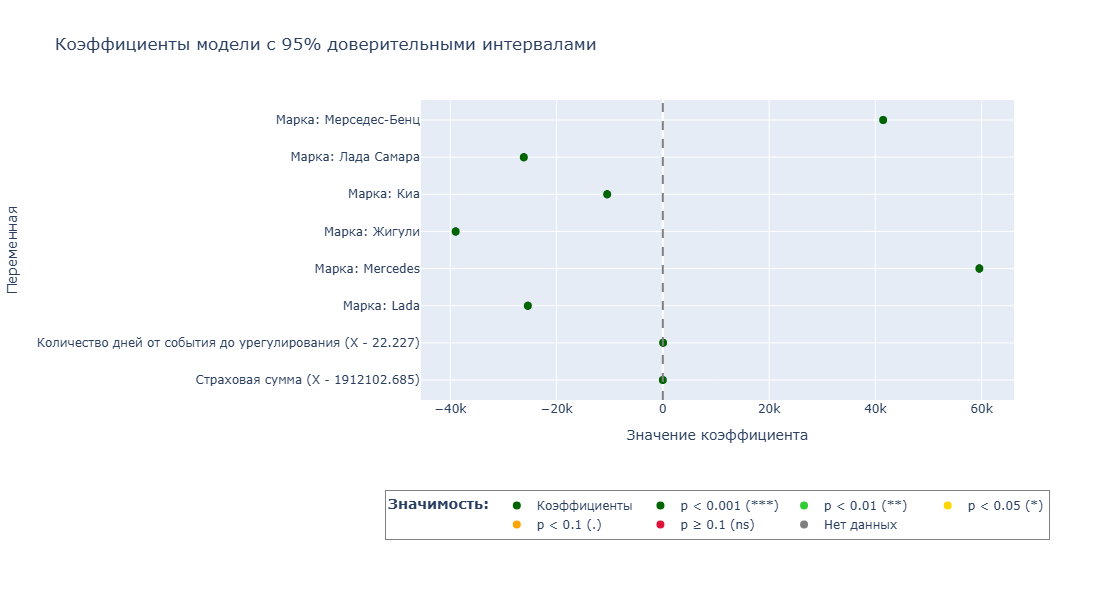

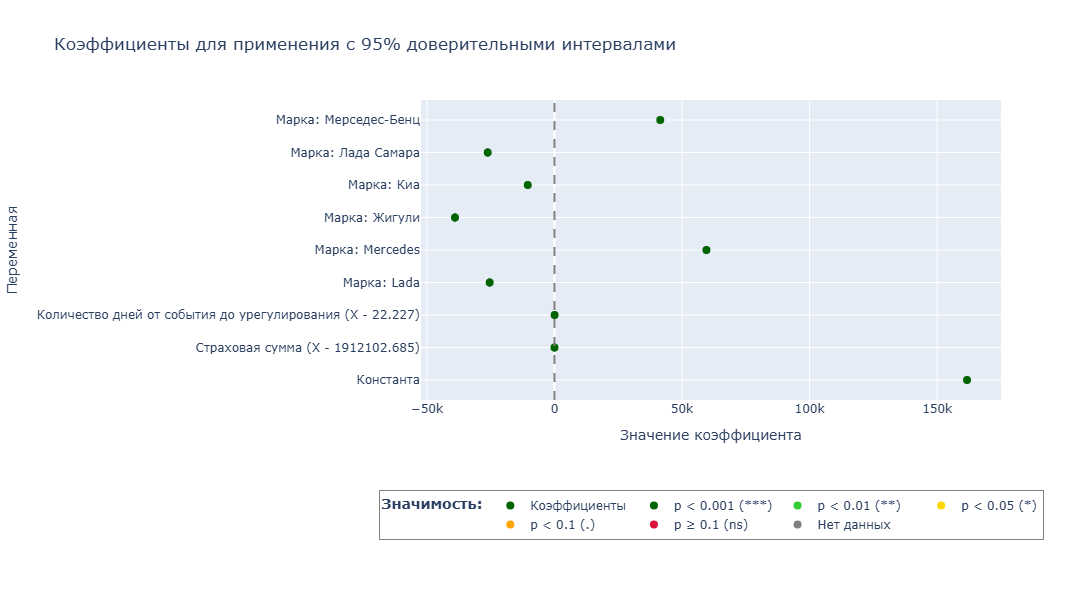

📈 Используется 1000 точек для графиков из 8000 общих
🔬 Семейство распределения: poisson
📊 Тип остатков по умолчанию: deviance


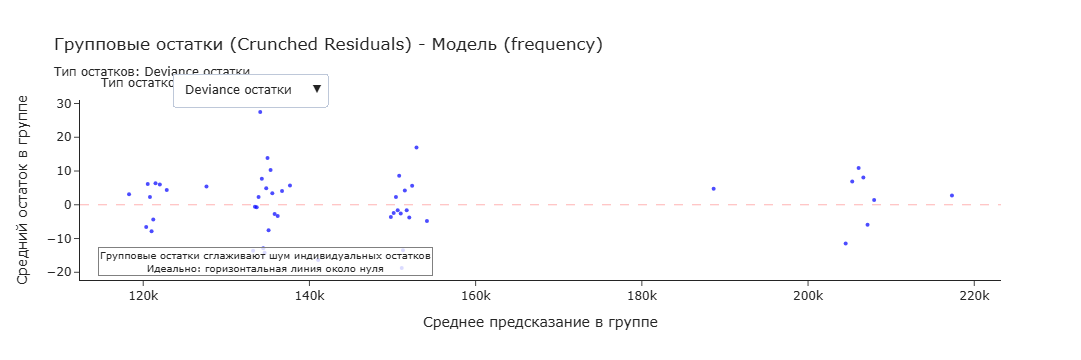

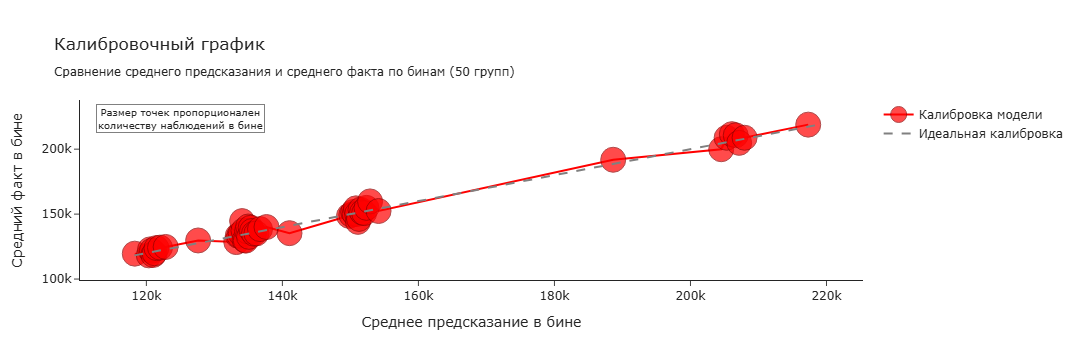

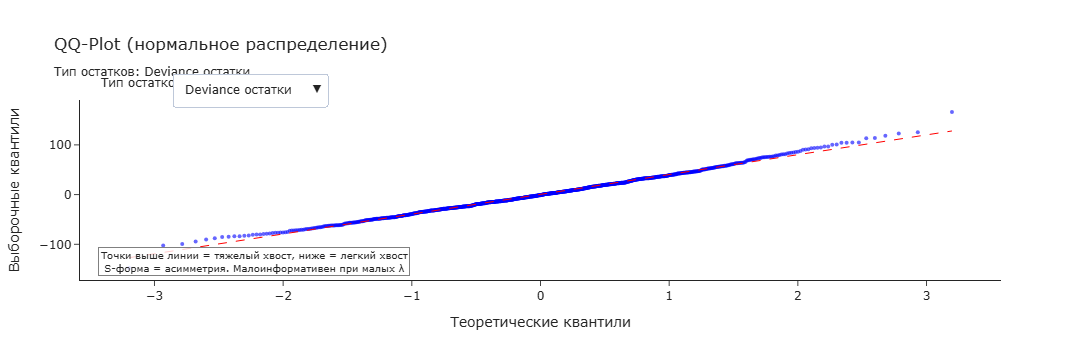

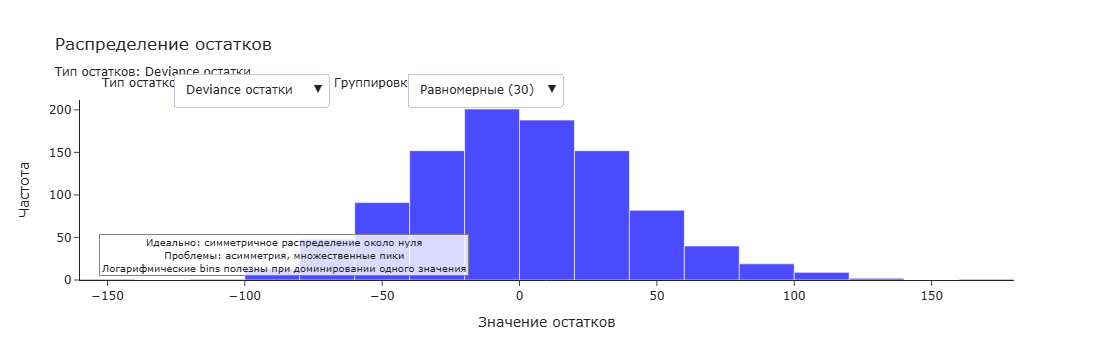

📑 Индекс графиков: model_analysis\research_transformers\b8b0d9136e9dd73810c41881cbb82553_index.html
✅ Анализ завершен! Результаты сохранены в: model_analysis\research_transformers
🎯 Построены графики, оптимизированные для модели frequency
✅ Модель сохранена: models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_model.pkl
✅ Метаданные сохранены: models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_metadata.yaml
Сохранены данные с хэшем b8b0d9136e9dd73810c41881cbb82553 в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_data.feather
✅ Данные автоматически сохранены в формате feather
Сохранен конфиг пайплайна в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_pipeline.yaml
✅ Pipeline YAML (конфиг) автоматически сохранен
Сохранен пайплайн в models\research_transformers\b8b0d9136e9dd73810c41881cbb82553_pipeline.joblib
🎯 Полный эксперимент сохранен с hash: b8b0d9136e9dd73810c41881cbb82553


'b8b0d9136e9dd73810c41881cbb82553'

In [120]:
output_dir = Path('model_analysis') / dataset_name
export_model_results(
    analysis_results,
    output_dir=str(output_dir),
    test_metrics=test_metrics,
    show_plots=True,
    model_type_hint='auto',
)

# Сохранение модели и пайплайна (для бук 3 и 4)
name_mapping = preprocessing_4glm_pipeline.steps[-1][1].get_column_mapping()
savem(
    name_mapping=name_mapping,
    dataset_name=dataset_name,
    pipeline=preprocessing_4glm_pipeline,
    df=df_model,
    analysis_results=analysis_results,
    model_dict=model_dict,
    file_extension=file_extension,
)